# Delamanid: how the signal changes under progressive adjustment

> **Bottom line.** As we adjust for lineage and resistance type, no single mutation's link to the delamanid MIC stays above the 0.5 reliability bar. The apparent lineage and type signals are background co-selection, not causes; the residual signal sits with the efflux-cluster mutations.

This notebook is the **comparison of the numbers**: how each mutation's selection frequency into `dlm_mic` moves as we add confounders (the causal graph pictures themselves are in `delamanid_stable_graphs.ipynb`).

- **baseline**: mutations only.
- **+lineage**: add phylogenetic lineage (corrected orientation: lineage is determined by the genome, so it is downstream of the mutations, never a cause of them).
- **+lineage +type**: also add resistance type (preXDR/XDR vs MDR). Note type is a *downstream* resistance readout, not an upstream cause: it is defined by resistance to other drugs (fluoroquinolones for preXDR; bedaquiline/linezolid for XDR), so it marks how heavily treated a strain is.

A credible direct driver keeps its frequency into `dlm_mic` as confounders are added; an artifact fades.

In [1]:
import sys; from pathlib import Path
sys.path.insert(0, str(Path.cwd().parents[2]))
from src.causal_discovery.cmm_utils import show_graph, parents_of, parents_across, plot_parents_across
LINFIX = 'tb_subsampling_dlm_mp4_k6_mcc4_linfix'
CONDS = {'baseline': f'{LINFIX}/baseline', '+lineage': f'{LINFIX}/with_lineage', '+lineage+type': f'{LINFIX}/with_lineage_and_type', 'type adj. out': f'{LINFIX}/with_lineage_and_type_forbid_type_to_mic'}

/Users/yasmineparent/internship/tb_internship/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/Users/yasmineparent/internship/tb_internship/.venv/lib/python3.12/site-packages/pgmpy/estimators/__init__.py:4: FutureWarning: `pgmpy.estimators.StructureScore` is deprecated and will be removed in a future release. Use `pgmpy.structure_score` instead.
  from .StructureScore import (


## Frequency into dlm_mic across conditions

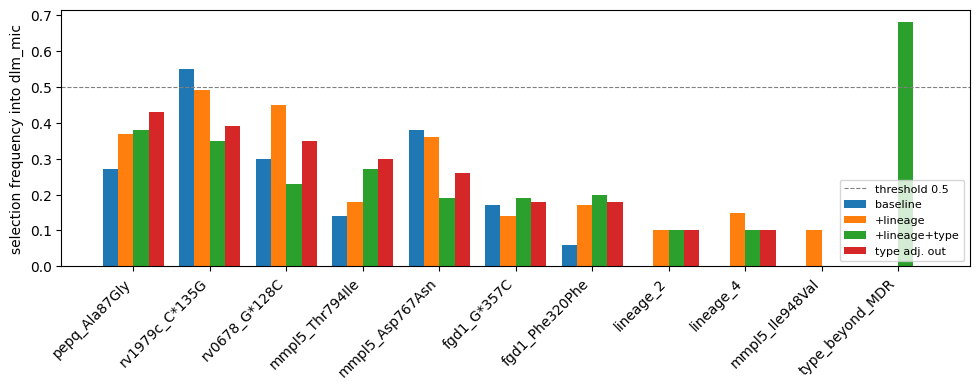

In [2]:
plot_parents_across(CONDS, 'dlm_mic')

In [3]:
parents_across(CONDS, 'dlm_mic')

,baseline,+lineage,+lineage+type,type adj. out
source,,,,
pepq_Ala87Gly,0.27,0.37,0.38,0.43
rv1979c_C*135G,0.55,0.49,0.35,0.39
rv0678_G*128C,0.30,0.45,0.23,0.35
mmpl5_Thr794Ile,0.14,0.18,0.27,0.30
mmpl5_Asp767Asn,0.38,0.36,0.19,0.26
fgd1_G*357C,0.17,0.14,0.19,0.18
fgd1_Phe320Phe,0.06,0.17,0.20,0.18
lineage_2,0.00,0.10,0.10,0.10
lineage_4,0.00,0.15,0.10,0.10


## Old (lineage-as-cause) vs corrected orientation

+lineage condition, parents of `dlm_mic`.

In [4]:
parents_across({'old (lineage cause)': 'tb_subsampling_dlm_mp4_k6_mcc4/with_lineage', 'corrected': f'{LINFIX}/with_lineage'}, 'dlm_mic')

,old (lineage cause),corrected
source,,
rv1979c_C*135G,0.39,0.49
rv0678_G*128C,0.06,0.45
pepq_Ala87Gly,0.51,0.37
mmpl5_Asp767Asn,0.08,0.36
mmpl5_Thr794Ile,0.02,0.18
fgd1_Phe320Phe,0.00,0.17
lineage_4,0.12,0.15
fgd1_G*357C,0.05,0.14
lineage_2,0.52,0.10


## What changed

`lineage_2 -> dlm_mic` collapses (0.52 -> 0.10) under the corrected orientation: it was an artifact of treating lineage as an upstream cause. The signal moves onto the efflux-cluster mutations.

**Resistance type behaves the same way.** When type is allowed to point into the MIC it dominates (~0.68), but that is treatment *co-selection*, not causation: type is defined by fluoroquinolone/bedaquiline/linezolid resistance, so it is a downstream marker of how heavily treated the strain is, not a cause of the delamanid MIC (delamanid is not in the type definition). Treated as downstream (type forbidden into the MIC), the signal returns to the mutations.

No single mutation clears 0.5, so the cautious conclusion stands; what changed is the attribution: the efflux-cluster mutations, not lineage or type.